# EDA

In [1]:
import sys
print(sys.version)
print(spark.version)

3.12.3 | packaged by conda-forge | (main, Apr 15 2024, 18:38:13) [GCC 12.3.0]
3.5.1


In [8]:
import os
import subprocess
import datetime
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql.types import *
from pyspark.sql.functions import *
from pyspark.ml.feature import Tokenizer, StopWordsRemover

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

In [4]:
reviews_path = "gs://msca-bdp-students-bucket/notebooks/sharonlee/Final Project/review_data"
meta_path = "gs://msca-bdp-students-bucket/notebooks/sharonlee/Final Project/meta_data"

In [5]:
reviews = spark.read.parquet(reviews_path)
meta = spark.read.parquet(meta_path)

In [7]:
reviews.printSchema()

root
 |-- asin: string (nullable = true)
 |-- helpful_vote: long (nullable = true)
 |-- parent_asin: string (nullable = true)
 |-- rating: double (nullable = true)
 |-- text: string (nullable = true)
 |-- title: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- verified_purchase: boolean (nullable = true)
 |-- timestamp_df: timestamp (nullable = true)


In [8]:
reviews.show(5)

+----------+------------+-----------+------+--------------------+--------------------+--------------------+-----------------+--------------------+
|      asin|helpful_vote|parent_asin|rating|                text|               title|             user_id|verified_purchase|        timestamp_df|
+----------+------------+-----------+------+--------------------+--------------------+--------------------+-----------------+--------------------+
|B00HSAOFD8|           0| B00HSAOFD8|   4.0|Brushes arrived q...|          Four Stars|AGWL43EG6H3AO3CN2...|             true| 2016-01-26 14:40:07|
|B07MGKRMBG|           0| B07SPY1GJG|   5.0|I have tried just...|Finally a natural...|AGUUIUEN3Y4X54WXM...|             true|2020-09-17 11:15:...|
|B01FOJ7EVO|           0| B09J7FM96G|   4.0|Love Mediheal but...|    Too small for me|AGOX7WJIY67A3OOKT...|             true|2020-12-06 18:42:...|
|B01B8ABHK2|           0| B016O0QZEO|   5.0|blended nicely wi...|             Quality|AH26NV6K35W6YPPWJ...|           

In [12]:
meta.printSchema()

root
 |-- parent_asin: string (nullable = true)
 |-- title: string (nullable = true)
 |-- main_category: string (nullable = true)
 |-- price: string (nullable = true)
 |-- average_rating: double (nullable = true)
 |-- rating_number: long (nullable = true)
 |-- price_num: double (nullable = true)


In [13]:
meta.show(5)

+-----------+--------------------+-------------+-----+--------------+-------------+---------+
|parent_asin|               title|main_category|price|average_rating|rating_number|price_num|
+-----------+--------------------+-------------+-----+--------------+-------------+---------+
| B005INGKNU|AX188 LEDGE 17x8,...|   Automotive| NULL|           4.4|            3|     NULL|
| B0B28JFFV2|EZISOE 50 Pcs Tir...|   Automotive|29.99|           4.6|          140|    29.99|
| B095YGCL6T|RISHNEG 200 Pcs C...|  Amazon Home| NULL|           4.0|            7|     NULL|
| B077L6RCTP|Speedy Pros I Bra...|   Automotive| NULL|           5.0|            1|     NULL|
| B072BQXHBG|Subaru Logo Tire ...|   Automotive|18.99|           4.5|          151|    18.99|
+-----------+--------------------+-------------+-----+--------------+-------------+---------+
only showing top 5 rows


### Timeline

In [27]:
reviews.select(
    F.min("timestamp_df").alias("min_timestamp"),
    F.max("timestamp_df").alias("max_timestamp"),
    F.count(F.when(F.col("timestamp_df").isNull(), 1)).alias("n_null_timestamp")
).show(truncate=False)

+-------------------+-----------------------+----------------+
|min_timestamp      |max_timestamp          |n_null_timestamp|
+-------------------+-----------------------+----------------+
|1998-01-19 16:58:28|2023-09-13 16:30:23.621|0               |
+-------------------+-----------------------+----------------+


In [41]:
# data collection gaps?

reviews_by_date = (
    reviews
    .withColumn("date", F.to_date("timestamp_df"))
    .groupBy("date")
    .count()
    .orderBy("date")
)

w = Window.orderBy("date")

daily_with_gap = (
    reviews_by_date
    .withColumn("prev_date", F.lag("date").over(w))
    .withColumn("gap_days", F.datediff(F.col("date"), F.col("prev_date")))
)
daily_with_gap.orderBy("gap_days", ascending=False).show(50, truncate=False)

+----------+-----+----------+--------+
|date      |count|prev_date |gap_days|
+----------+-----+----------+--------+
|1999-06-15|1    |1999-02-03|132     |
|1998-12-05|1    |1998-09-21|75      |
|1999-10-20|1    |1999-08-28|53      |
|1998-09-12|1    |1998-07-28|46      |
|1998-06-08|1    |1998-04-24|45      |
|1999-08-17|1    |1999-07-06|42      |
|1999-01-15|1    |1998-12-05|41      |
|1998-04-22|1    |1998-03-20|33      |
|1998-07-09|2    |1998-06-08|31      |
|1999-11-18|1    |1999-10-20|29      |
|1998-02-11|1    |1998-01-19|23      |
|1998-03-20|1    |1998-02-25|23      |
|2000-10-14|1    |2000-09-22|22      |
|1999-12-26|1    |1999-12-06|20      |
|1999-02-03|1    |1999-01-15|19      |
|2000-05-21|1    |2000-05-03|18      |
|2000-03-18|1    |2000-03-02|16      |
|1999-12-06|1    |1999-11-22|14      |
|1998-07-28|1    |1998-07-15|13      |
|1999-06-28|1    |1999-06-15|13      |
|2000-06-04|1    |2000-05-23|12      |
|1999-08-28|1    |1999-08-17|11      |
|2000-01-17|1    |2000-01

In [34]:
# potential outliers?
stats = reviews_by_date.select(
    F.mean("count").alias("mean_count"),
    F.stddev("count").alias("std_count")
).first()
mean_count = stats["mean_count"]
std_count = stats["std_count"]

upper = mean_count + 3*std_count
lower = max(mean_count - 3*std_count, 0)

high_outliers = reviews_by_date.filter(F.col("count") > upper)
low_outliers = reviews_by_date.filter(
    (F.col("count") < lower) & (F.col("count") > 0)
)


print("High-volume outlier days:")
high_outliers.orderBy("date").show(50, truncate=False)

print("Low-volume outlier days:")
low_outliers.orderBy("date").show(50, truncate=False)

High-volume outlier days:


+----------+-----+
|date      |count|
+----------+-----+
|2019-12-12|42021|
|2019-12-13|40612|
|2019-12-14|41924|
|2019-12-15|42964|
|2019-12-16|43447|
|2019-12-17|40868|
|2019-12-26|38777|
|2019-12-27|40604|
|2019-12-28|38425|
|2019-12-29|39857|
|2019-12-30|40852|
|2019-12-31|41938|
|2020-01-02|42939|
|2020-01-03|40487|
|2020-01-04|39459|
|2020-01-05|44582|
|2020-01-06|42561|
|2020-01-07|39887|
|2020-01-08|37998|
|2020-01-10|40765|
|2020-01-11|38580|
|2020-01-12|41644|
|2021-04-08|39201|
+----------+-----+

Low-volume outlier days:


+----+-----+
|date|count|
+----+-----+
+----+-----+


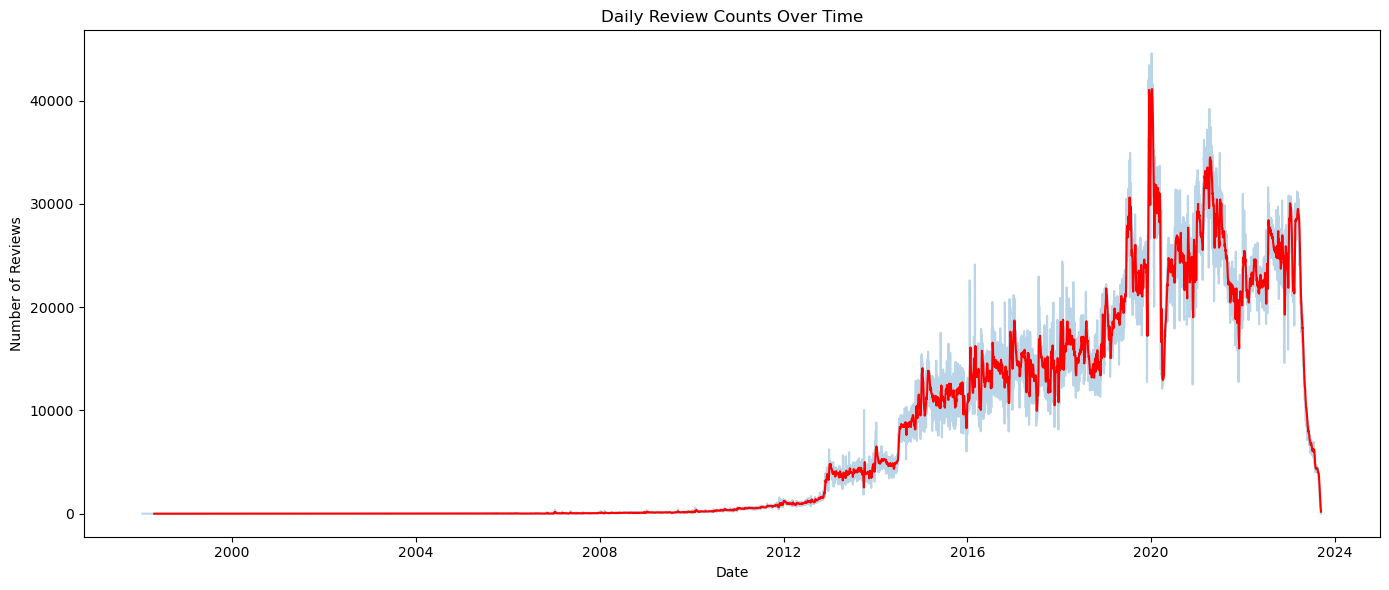

In [45]:
# graph for daily review counts over time 
reviews_daily_df = reviews_by_date.toPandas()
reviews_daily_df = reviews_daily_df.sort_values("date")
reviews_daily_df["rolling_7"] = reviews_daily_df["count"].rolling(7).mean()

plt.figure(figsize=(14, 6))
plt.plot(reviews_daily_df["date"], reviews_daily_df["count"], alpha=0.3, label="Daily")
plt.plot(reviews_daily_df["date"], reviews_daily_df["rolling_7"], color="red", label="Weekly")
plt.title("Daily Review Counts Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Reviews")

plt.tight_layout()
plt.show()

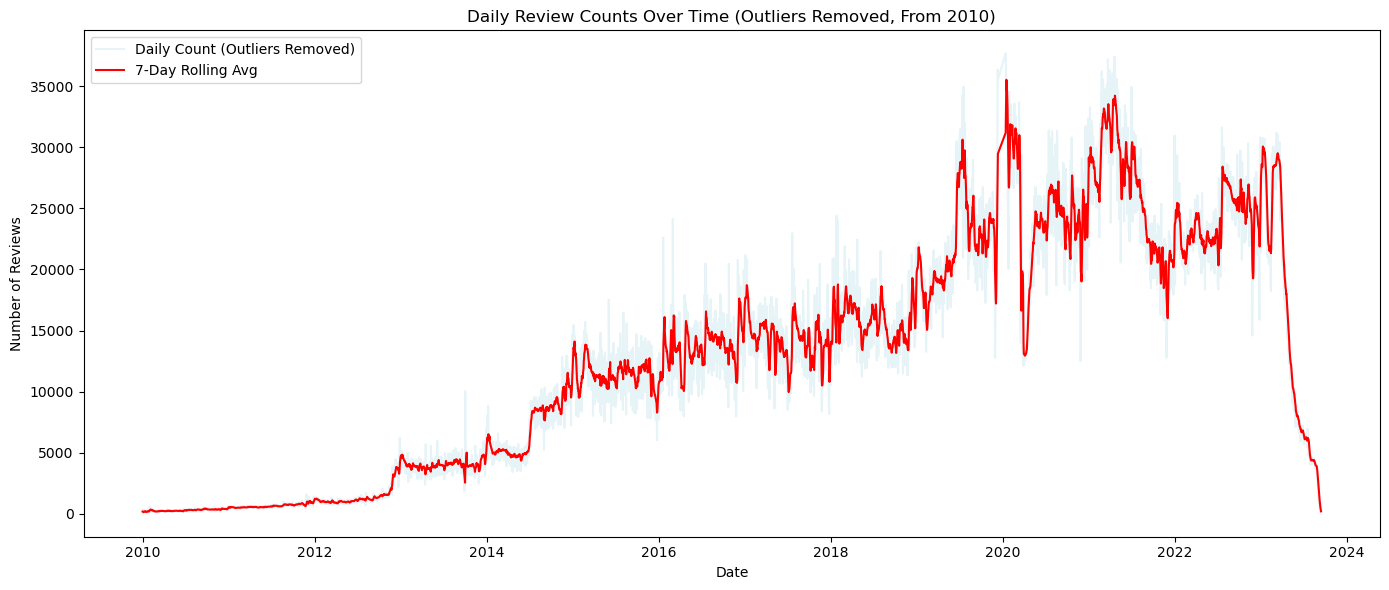

In [46]:
# from 2010, removed outliers
reviews_daily_df["date"] = pd.to_datetime(reviews_daily_df["date"])

outlier_start = pd.to_datetime("2019-12-12")
outlier_end   = pd.to_datetime("2020-01-12")
outlier_single = pd.to_datetime("2021-04-08")

pdf_no_outliers = reviews_daily_df[
    ~(
        ((reviews_daily_df["date"] >= outlier_start) & (reviews_daily_df["date"] <= outlier_end)) |
        (reviews_daily_df["date"] == outlier_single)
    )
]
pdf_no_outliers = pdf_no_outliers.sort_values("date")
pdf_no_outliers["rolling_7"] = pdf_no_outliers["count"].rolling(7, min_periods=1).mean()
pdf_no_outliers_2010 = pdf_no_outliers[pdf_no_outliers["date"] >= "2010-01-01"]

plt.figure(figsize=(14, 6))

plt.plot(
    pdf_no_outliers_2010["date"], 
    pdf_no_outliers_2010["count"],
    alpha=0.3,
    color="lightblue",
    label="Daily Count (Outliers Removed)"
)
plt.plot(
    pdf_no_outliers_2010["date"],
    pdf_no_outliers_2010["rolling_7"],
    color="red",
    label="7-Day Rolling Avg"
)
plt.title("Daily Review Counts Over Time (Outliers Removed, From 2010)")
plt.xlabel("Date")
plt.ylabel("Number of Reviews")
plt.legend()
plt.tight_layout()
plt.show()

**The timeline of the data?**  
The review dataset spans from January 1998 through September 2023.

**Significant peaks and valleys?**  
Across years, review activity consistently shows seasonal patterns, with spikes during the December-January period and occasional increases in the middle of the year. The most noticeable spike occurs from December 2019 through early January 2020, where daily review counts exceeded 40,000 reviews per day. The period stands out even relative to typical holiday-season effects and is later identified as a high-volume outlier.  

**Data collection gaps?**  
The dataset contains noticeable gaps only in the earliest years. The largest gap occurs between February 3, 1999 and June 15, 1999, and all significant gaps are concentrated between 1998 and 2000. After 2000, gaps are much smaller (typically within 7 days), which suggests more consistent and complete data collection from that point forward.  

**Any outliers?**  
As noted earlier, the spike from December 12, 2019 through January 12, 2020 exceeds 40,000 daily reviews. In addition, there is a single high-volume day on April 8, 2021, which also approaches 40,000 reviews. 

**Are these spikes caused by real activities / events?**  
The recurring peaks seem to reflect real activity, since they occur during the December-January period and again in the middle of the year. People tend to spend more during the holiday season, and Amazon Prime Day happens in July, which likely contributes to the mid-year increases. However, the spike around the transition into 2020 is far larger than any other holiday season and stays near 40,000 reviews a day for a month, so it may come from how the data was collected rather than from real demand. I treat it as an outlier.

### Top 10 products with most reviews

In [66]:
top10_asin = (
    reviews.groupBy("parent_asin")
          .count()
          .orderBy(F.col("count").desc())
          .limit(10)
)
top10_products = (
    top10_asin.join(meta, on="parent_asin", how="left")
)
top10_products.show()

+-----------+-----+--------------------+--------------------+-----+--------------+-------------+---------+
|parent_asin|count|               title|       main_category|price|average_rating|rating_number|price_num|
+-----------+-----+--------------------+--------------------+-----+--------------+-------------+---------+
| B01415QHYW|43229|amFilm Screen Pro...|Cell Phones & Acc...| 6.98|           4.6|       131143|     6.98|
| B07H2V5YLH|24786|Ailun Glass Scree...|Cell Phones & Acc...| 7.98|           4.6|       354024|     7.98|
| B073R68TSH|25606|Beam Electronics ...|Cell Phones & Acc...|19.99|           4.2|        85828|    19.99|
| B01LSUQSB0|37164|REVLON One-Step V...|          All Beauty| 38.8|           4.6|       335286|     38.8|
| B07P9S6R9Y|29285|Yootech Wireless ...|     All Electronics|15.99|           4.3|       191581|    15.99|
| B0BVGHXZJ1|34120|essence | Lash Pr...|          All Beauty| 4.99|           4.3|       340182|     4.99|
| B01ITNRGFG|25571|JOTO Universal Wa.

/tmp/ipykernel_78/1714078431.py:39: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


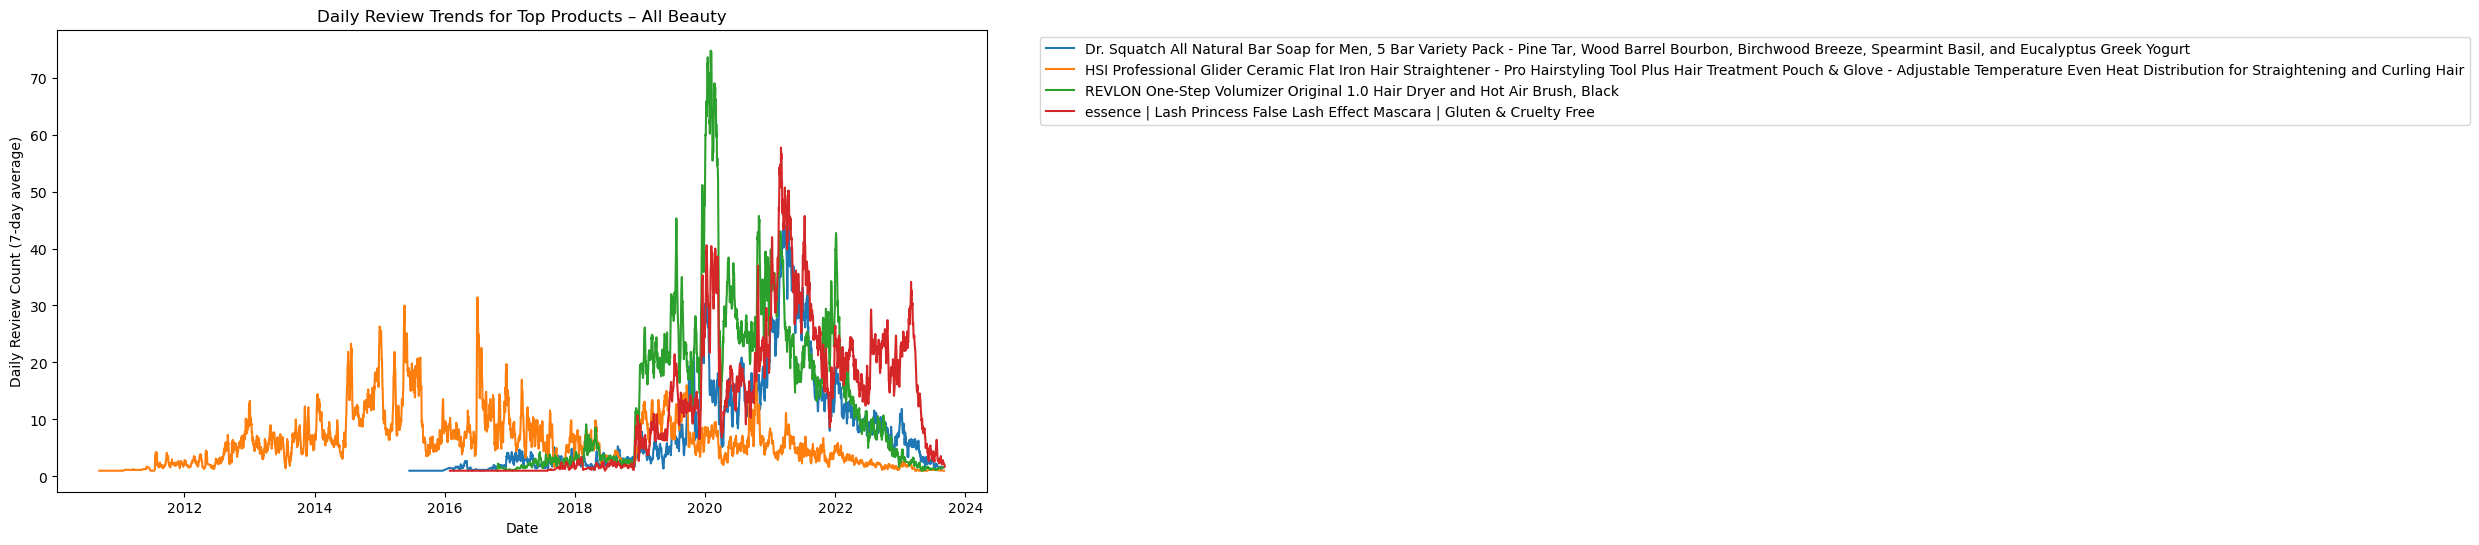

/tmp/ipykernel_78/1714078431.py:39: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


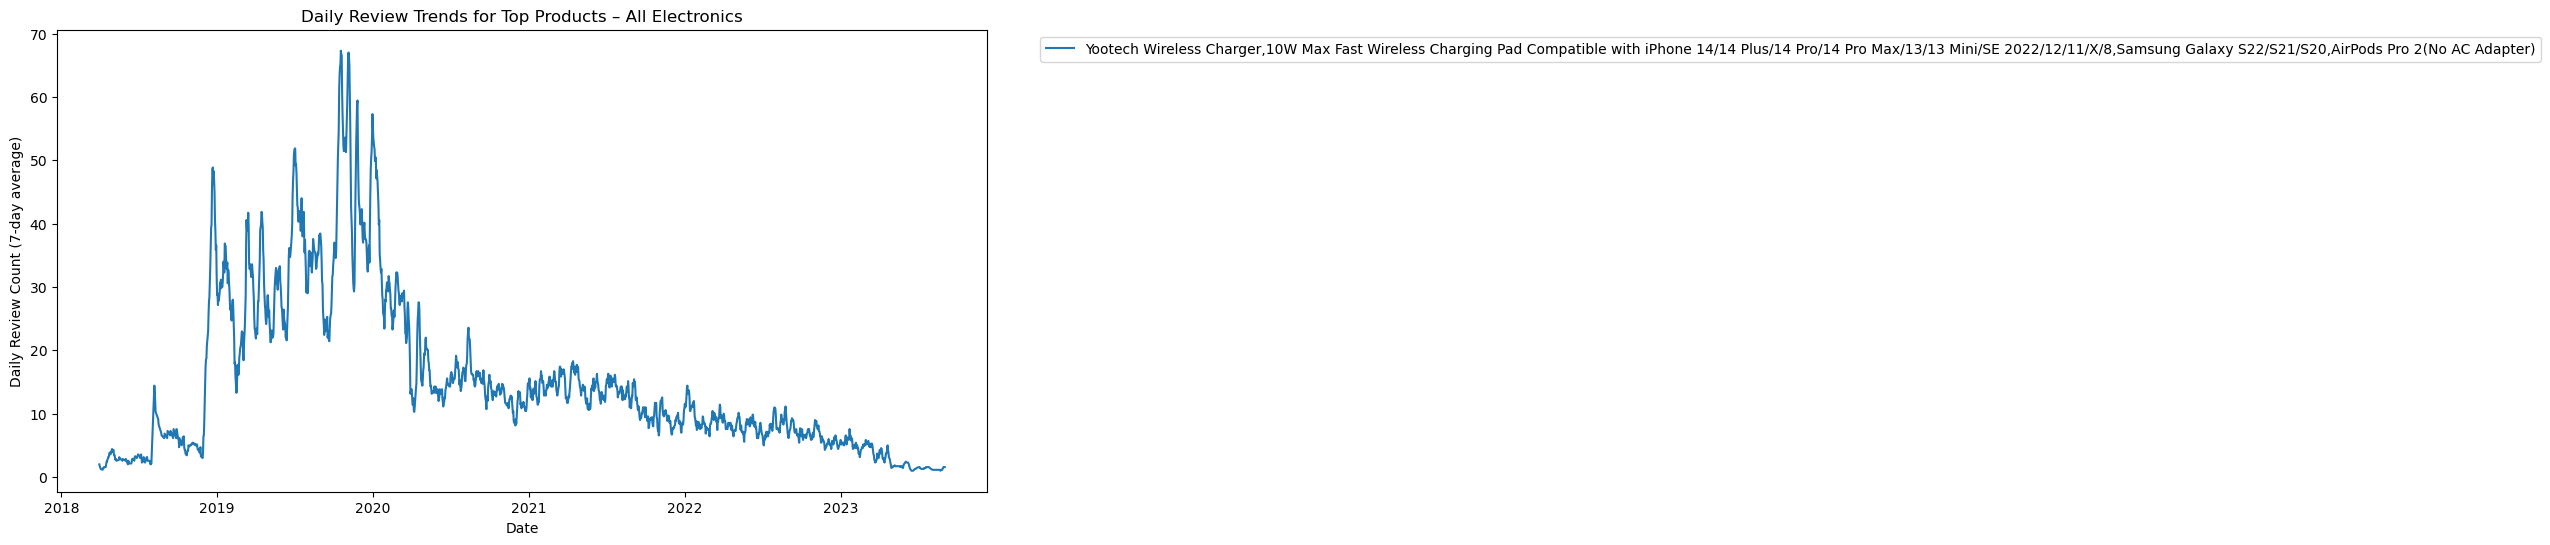

/tmp/ipykernel_78/1714078431.py:39: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


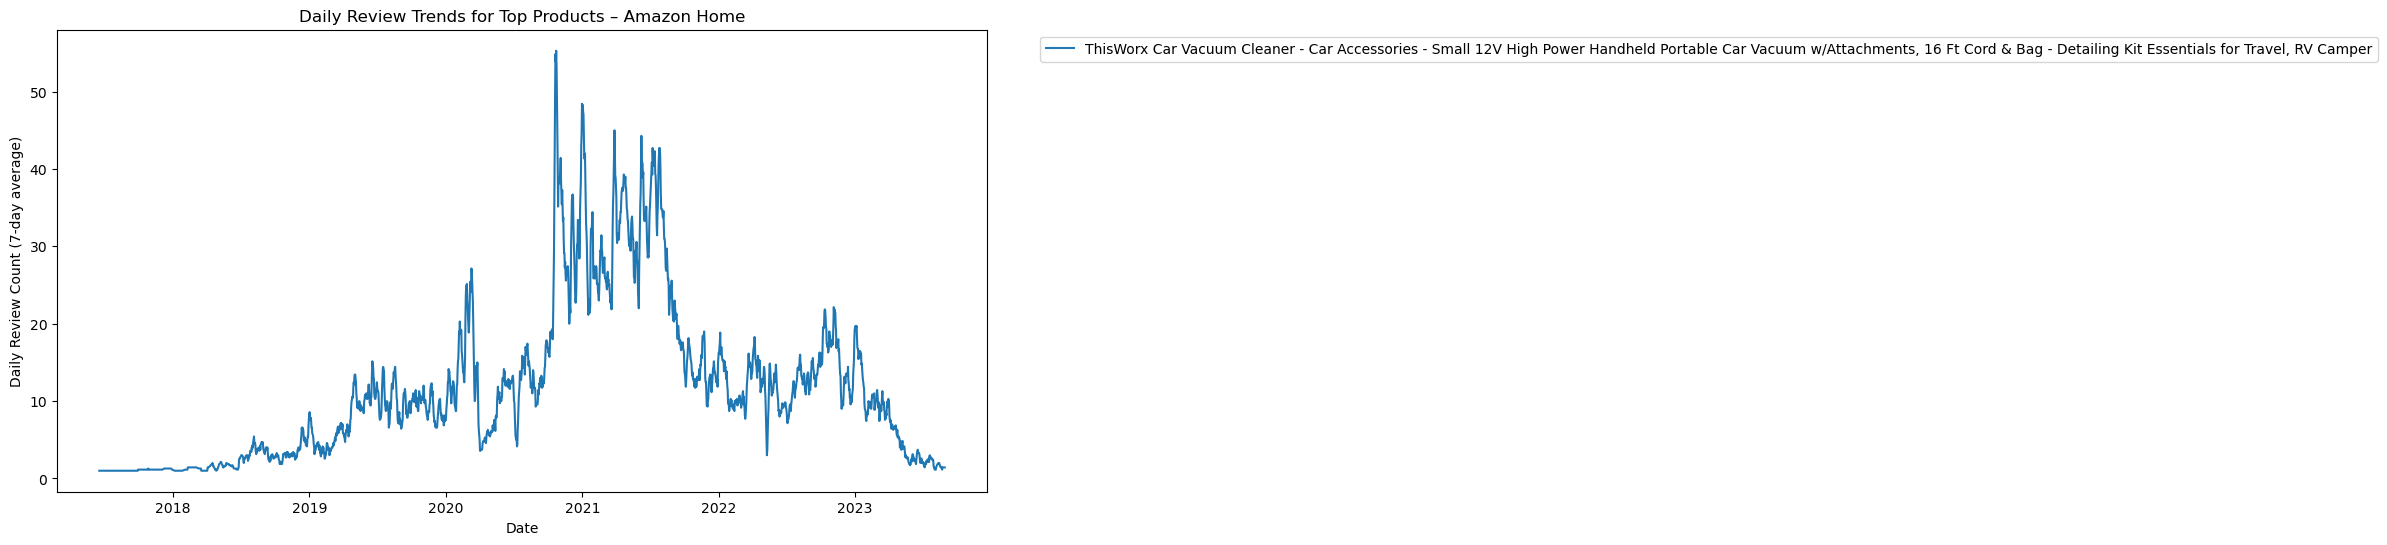

/tmp/ipykernel_78/1714078431.py:39: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


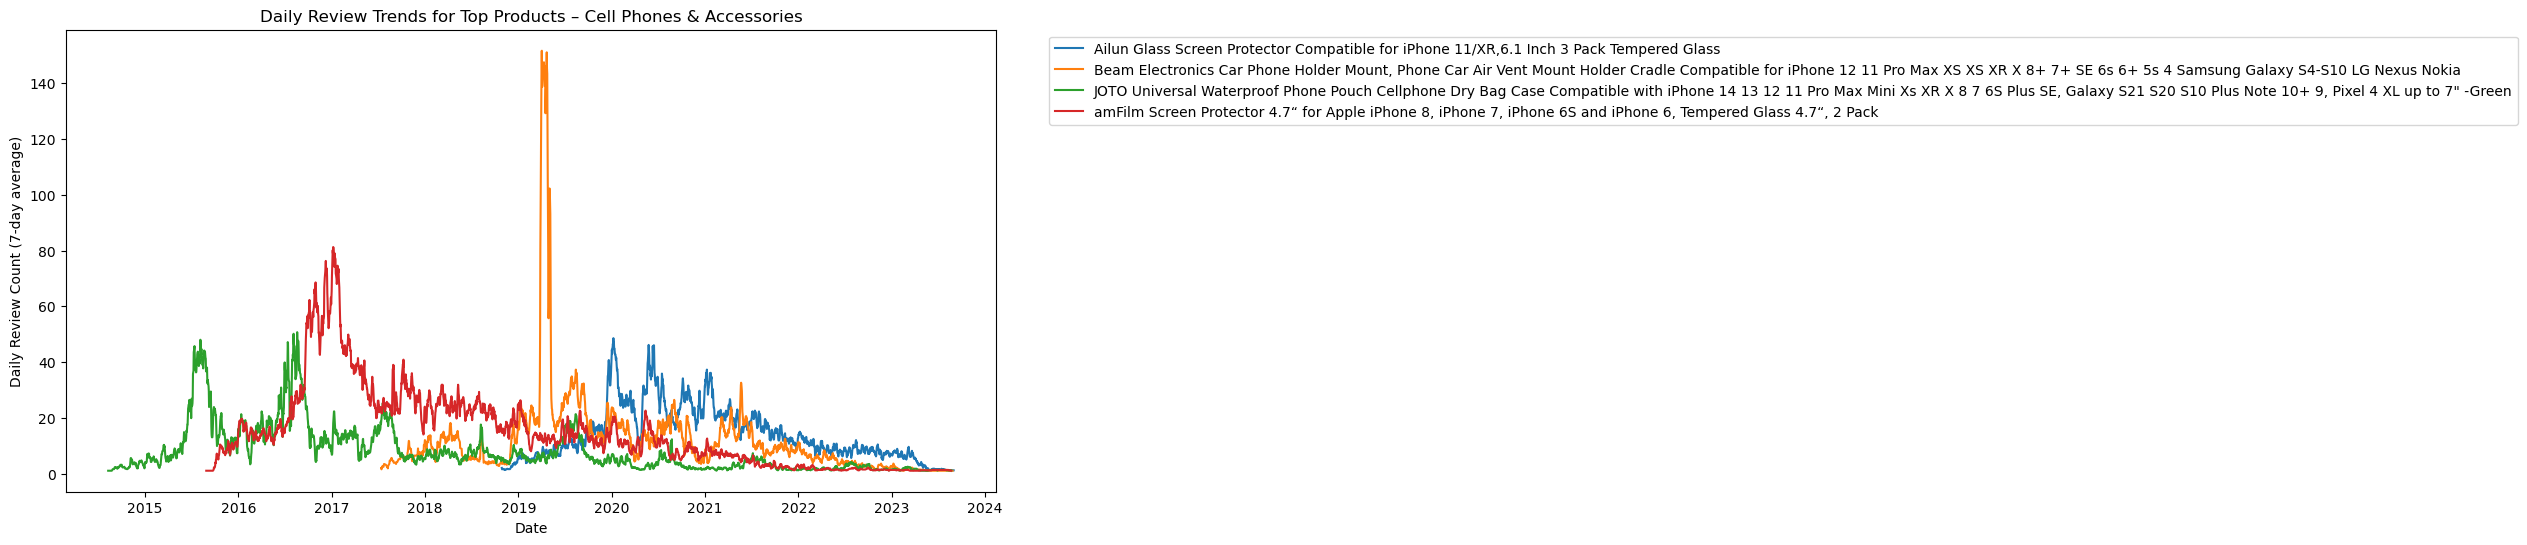

In [68]:
reviews_top10 = (
    reviews.join(F.broadcast(top10_asin.select("parent_asin")), on="parent_asin", how="inner")
)
reviews_top10_with_meta = (
    reviews_top10.join(
        meta.select("parent_asin", F.col("title").alias("product_title"), "main_category"),
        on="parent_asin",
        how="left"
    )
)
top10_daily = (
    reviews_top10_with_meta
    .withColumn("date", F.to_date("timestamp_df"))
    .groupBy("main_category", "product_title", "parent_asin", "date")
    .count()
)

w = Window.partitionBy("parent_asin").orderBy("date").rowsBetween(-6, 0)

top10_daily = (
    top10_daily
    .withColumn("count_7d_avg", F.avg("count").over(w))
)

pdf = top10_daily.toPandas()
pdf = pdf.sort_values(["main_category", "product_title", "date"])

for cat, df_cat in pdf.groupby("main_category"):
    plt.figure(figsize=(12, 6))

    for title, df_prod in df_cat.groupby("product_title"):
        df_prod = df_prod.sort_values("date")
        plt.plot(df_prod["date"], df_prod["count_7d_avg"], label=title)

    plt.title(f"Daily Review Trends for Top Products – {cat}")
    plt.xlabel("Date")
    plt.ylabel("Daily Review Count (7-day average)")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

**What are the top 10 products with the most reviews?**  
The top 10 products with the highest review volume are screen protectors, car phone mounts, hair tools, beauty products, a wireless charger, and a car vacuum, with total review counts ranging from roughly 24,000 to over 43,000. Most of these products fall within Cell Phones & Accessories and Beauty.

**How does their review count trend over time?**  
Across all products, review trends follow a similar pattern: gradual early growth, a sharp rise during peak popularity, and a steady decline. Several products show strong spikes around 2019-2020, aligning with the overall review timeline.

### Review volume across categories

In [69]:
distinct_categories = meta.select("main_category").distinct()
distinct_categories.show()

+--------------------+
|       main_category|
+--------------------+
|           Computers|
|     All Electronics|
|             Grocery|
|               Books|
|         Amazon Home|
|Cell Phones & Acc...|
|Arts, Crafts & Se...|
|      Amazon Devices|
|       Digital Music|
|        Buy a Kindle|
|                Baby|
|          Automotive|
|            Handmade|
|      Apple Products|
|Portable Audio & ...|
|      AMAZON FASHION|
|        Pet Supplies|
|   Sports & Outdoors|
|Industrial & Scie...|
|Tools & Home Impr...|
+--------------------+
only showing top 20 rows


In [70]:
category_counts = (
    meta.groupBy("main_category")
        .count()
        .orderBy("count", ascending = False)
)
category_counts = category_counts.toPandas()

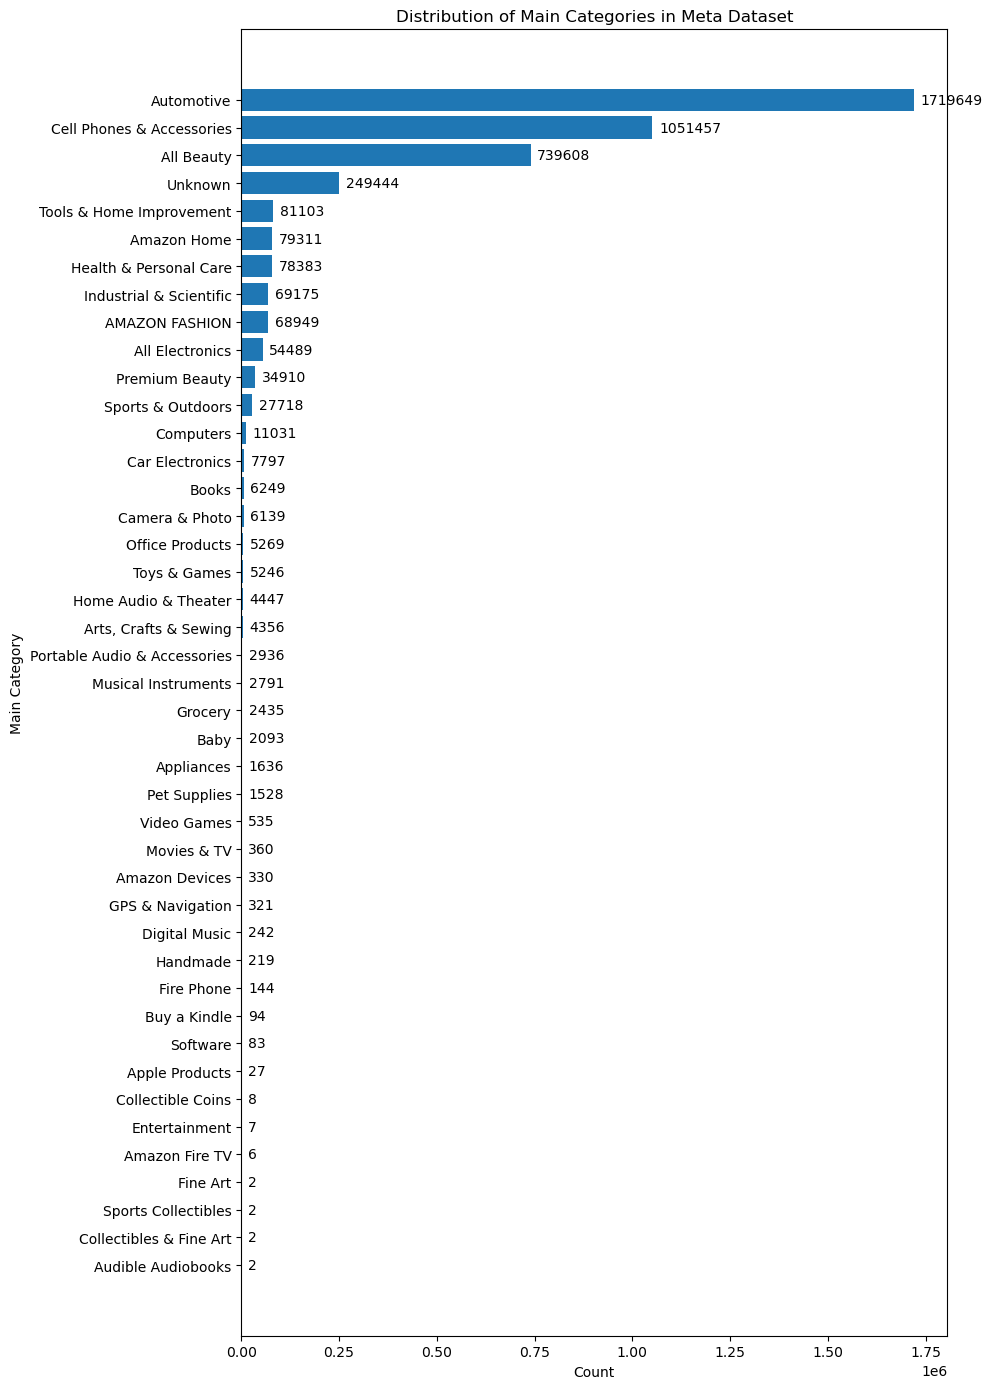

In [72]:
# bar chart for distribution of main categories
category_counts["main_category"] = category_counts["main_category"].fillna("Unknown")

plt.figure(figsize=(10, 14)) 

plt.barh(category_counts["main_category"], category_counts["count"])
plt.xlabel("Count")
plt.ylabel("Main Category")
plt.title("Distribution of Main Categories in Meta Dataset")

for i, v in enumerate(category_counts["count"]):
    plt.text(
        v + max(category_counts["count"])*0.01,        
        i,                   
        str(v),                           
        va='center'
    )

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

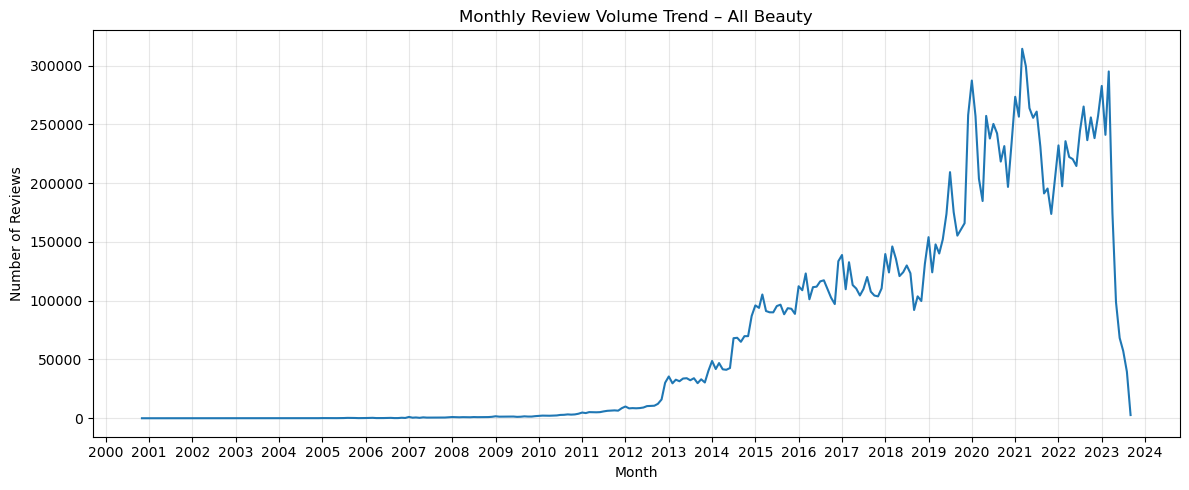

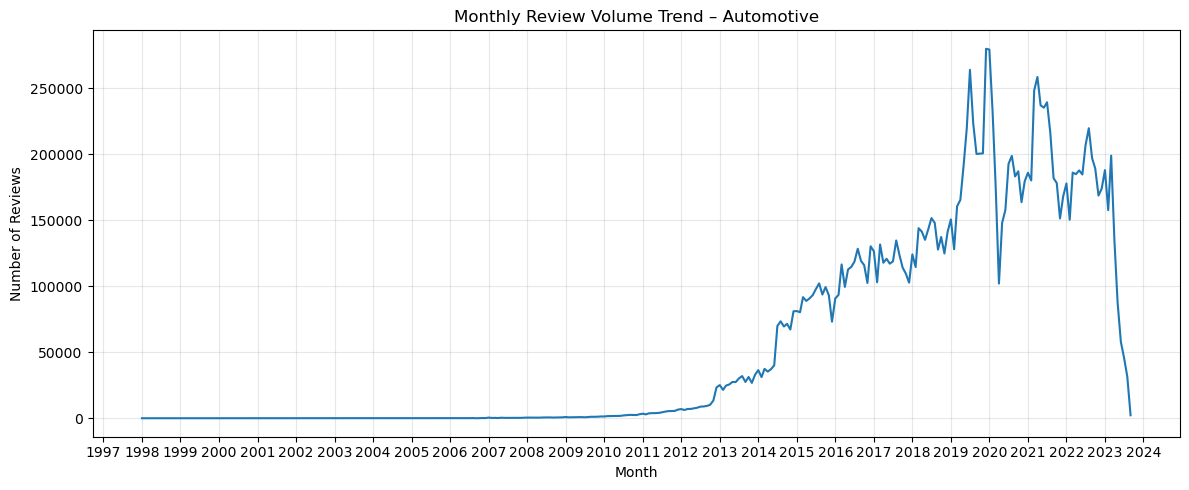

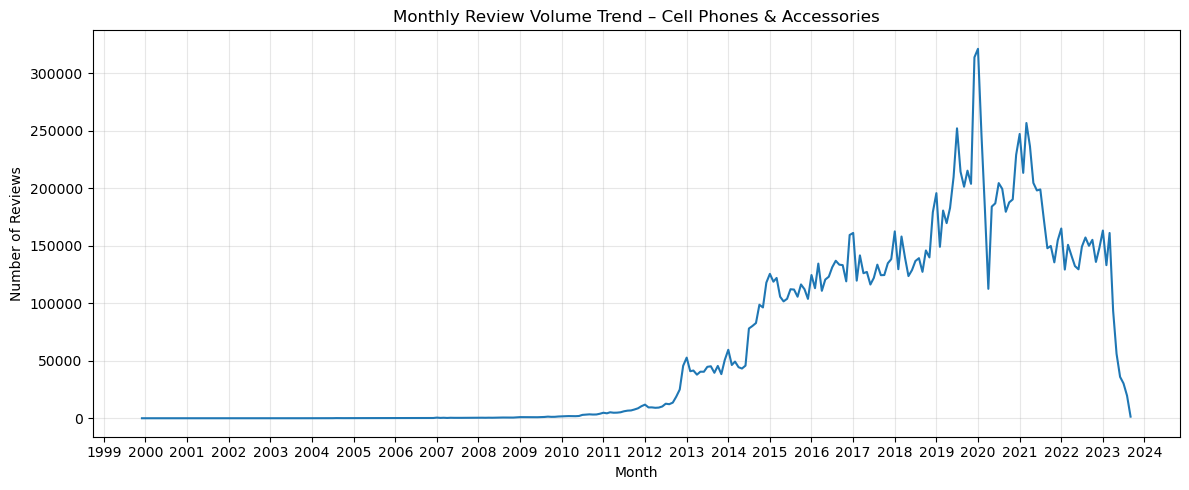

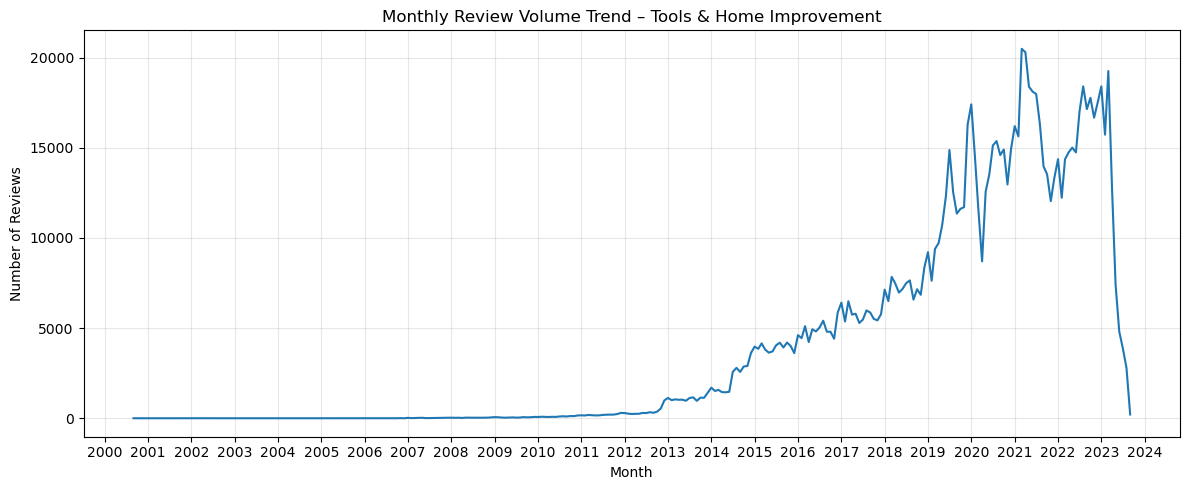

In [75]:
target_categories = [ # top 5 categories
    "Automotive",
    "Cell Phones & Accessories",
    "All Beauty",
    "Unknown",
    "Tools & Home Improvement"
]
reviews_with_cat = (
    reviews.join(
        meta.select("parent_asin", "main_category"),
        on="parent_asin",
        how="left"
    )
)
filtered = reviews_with_cat.filter(F.col("main_category").isin(target_categories))
filtered_monthly = (
    filtered.withColumn("year_month", F.date_format(F.col("timestamp_df"), "yyyy-MM"))
            .groupBy("main_category", "year_month")
            .count()
            .orderBy("main_category", "year_month")
)

pdf = filtered_monthly.toPandas()
pdf["year_month"] = pd.to_datetime(pdf["year_month"])
pdf = pdf.sort_values(["main_category", "year_month"])

import matplotlib.dates as mdates

for category, df_cat in pdf.groupby("main_category"):
    plt.figure(figsize=(12, 5))
    
    plt.plot(df_cat["year_month"], df_cat["count"], label=category, color="tab:blue")
    
    plt.title(f"Monthly Review Volume Trend – {category}")
    plt.xlabel("Month")
    plt.ylabel("Number of Reviews")
    
    plt.gca().xaxis.set_major_locator(mdates.YearLocator(1))
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

**Do certain categories see spikes in review volume during specific months (e.g., holidays, sales)?**  
Monthly review volume trends were assessed for the largest categories: Automotive, Cell Phones & Accessories, All Beauty, and Tools & Home Improvement. Products with no category are null in Spark rather than "Unknown", so that group was not plotted. They all show clear seasonal spikes in review volumes. Review activity rises gradually from 2012, surges sharply beginning in 2019, and reaches its largest peak during the December 2019-January 2020 period. All four categories also show mid-year spikes (around July-August) and end-of-year increases, consistent with major sales events and holiday shopping seasons.

### High ratings -> most reviewed?

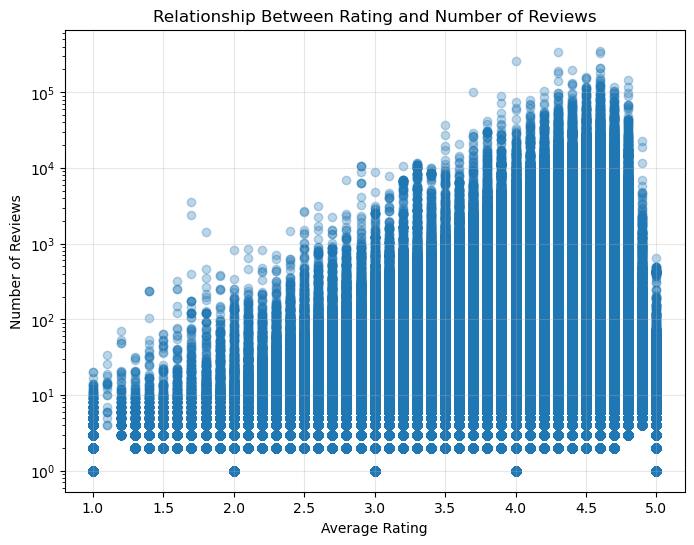

In [76]:
pdf = meta.select("average_rating", "rating_number").toPandas()

plt.figure(figsize=(8,6))
plt.scatter(pdf["average_rating"], pdf["rating_number"], alpha=0.3)
plt.xlabel("Average Rating")
plt.ylabel("Number of Reviews")
plt.title("Relationship Between Rating and Number of Reviews")
plt.yscale("log") 
plt.grid(True, alpha=0.3)
plt.show()

The scatterplot shows that products with extremely high average rating (4.5-5.0) are generally not the most reviewed. High-volume products tend to have slightly lower but more stable ratings in the 4.3-4.7 range, while 4.9-5.0 ratings are generally associated with small review counts.

### Product price vs. average rating/review volume?

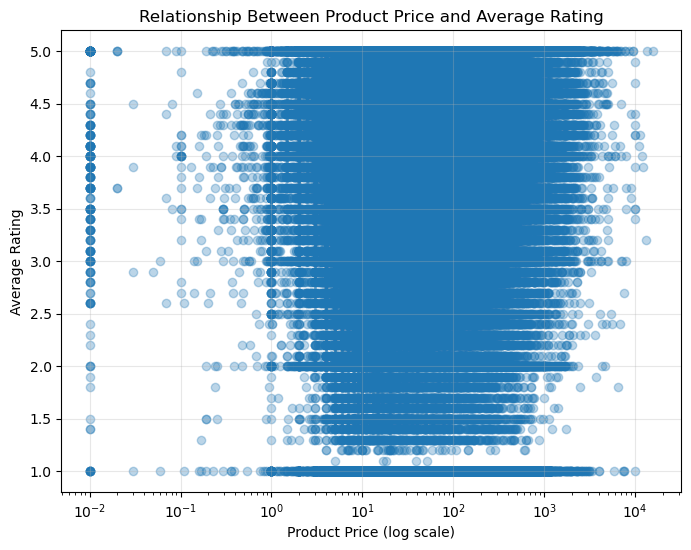

In [77]:
# product price vs. average rating
price_rating = (
    meta.select("price_num", "average_rating")
        .filter((F.col("price_num").isNotNull()) & (F.col("average_rating").isNotNull()))
)

pdf = price_rating.toPandas()

plt.figure(figsize=(8,6))
plt.scatter(pdf["price_num"], pdf["average_rating"], alpha=0.3)

plt.xscale("log")
plt.xlabel("Product Price (log scale)")
plt.ylabel("Average Rating")
plt.title("Relationship Between Product Price and Average Rating")
plt.grid(True, alpha=0.3)

plt.show()

In [79]:
# correlation?
corr = pdf["price_num"].corr(pdf["average_rating"], method="spearman")
corr

0.05710022011044862

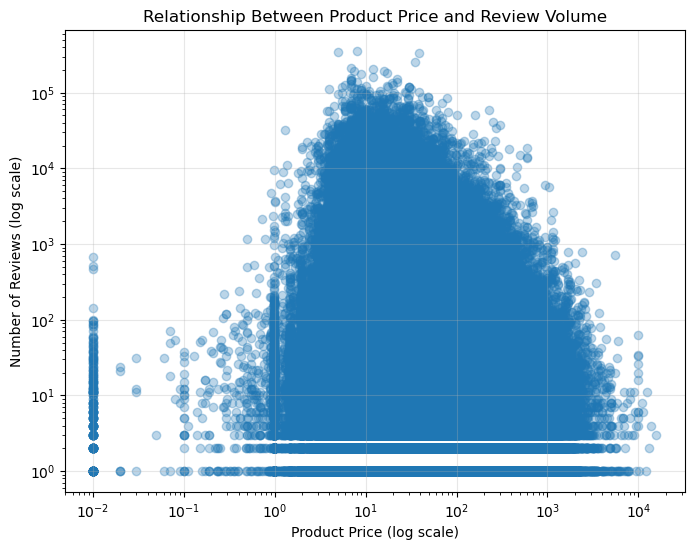

In [80]:
# product price vs. review volume
price_volume = (
    meta.select("price_num", "rating_number")
        .filter(
            (F.col("price_num").isNotNull()) &
            (F.col("rating_number").isNotNull()) &
            (F.col("price_num") > 0)
        )
)
pdf = price_volume.toPandas()

plt.figure(figsize=(8,6))
plt.scatter(pdf["price_num"], pdf["rating_number"], alpha=0.3)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Product Price (log scale)")
plt.ylabel("Number of Reviews (log scale)")
plt.title("Relationship Between Product Price and Review Volume")
plt.grid(True, alpha=0.3)

plt.show()

In [82]:
# correlation?
corr = pdf["price_num"].corr(pdf["rating_number"], method="spearman")
corr

-0.18587392110222112

There is no strong relationship between a product's price and its average rating or review volume. Ratings are widely distributed across all price levels, indicating that expensive products are not rated more favorably than cheaper ones. Review volume tends to peak for mid-priced items (approximately $5-$50), while both very low-priced and very high-priced products attract fewer reviews, suggesting that consumer demand and product category, not price, drive popularity.

### Common words in 5-star vs. 1-star reviews

In [12]:
reviews_text = (
    reviews.select("rating", "text")
           .filter(F.col("text").isNotNull())
)

df_5 = reviews.select("rating", "text").filter(F.col("rating") == 5)
df_1 = reviews.select("rating", "text").filter(F.col("rating") == 1)
    
# remove punctuation and split into words
df_5 = df_5.withColumn("clean_text", F.regexp_replace(F.col("text"), "[^a-zA-Z0-9\\s]", ""))
df_1 = df_1.withColumn("clean_text", F.regexp_replace(F.col("text"), "[^a-zA-Z0-9\\s]", ""))
df_5 = df_5.withColumn("text_words", split(F.col("clean_text"), " "))
df_1 = df_1.withColumn("text_words", split(F.col("clean_text"), " "))

# filter out tokens < 3 characters (remove 'is', 'a', 'am', etc)
df_5 = df_5.withColumn("clean_text_words", F.expr("filter(text_words, word -> length(word) >= 3)"))
df_1 = df_1.withColumn("clean_text_words", F.expr("filter(text_words, word -> length(word) >= 3)"))

# remove stopwords
remover_text = StopWordsRemover(inputCol="clean_text_words", outputCol="filtered_text_words")
df_5 = remover_text.transform(df_5)
df_1 = remover_text.transform(df_1)

In [16]:
words_5 = df_5.select(F.explode("filtered_text_words").alias("word"))
words_1 = df_1.select(F.explode("filtered_text_words").alias("word"))

top_words_5 = words_5.groupBy("word").count().orderBy(F.col("count").desc()).limit(30)
top_words_1 = words_1.groupBy("word").count().orderBy(F.col("count").desc()).limit(30)

In [17]:
top_words_5.show(30, truncate=False)
top_words_1.show(30, truncate=False)

+---------+-------+
|word     |count  |
+---------+-------+
|great    |7591811|
|product  |6252865|
|phone    |5119755|
|like     |5039428|
|use      |4889269|
|good     |4679804|
|case     |4633184|
|one      |4514298|
|love     |4332004|
|well     |4176245|
|hair     |4120342|
|easy     |3859652|
|Great    |3636623|
|really   |2779407|
|price    |2753680|
|works    |2709186|
|get      |2574279|
|time     |2487130|
|quality  |2446787|
|Love     |2434618|
|fit      |2393511|
|used     |2364474|
|Ive      |2251275|
|nice     |2250937|
|perfect  |2226681|
|recommend|2187414|
|skin     |2108000|
|install  |2012787|
|little   |1995602|
|much     |1989551|
+---------+-------+


+-------+-------+
|word   |count  |
+-------+-------+
|product|1447243|
|phone  |1297314|
|one    |1266283|
|like   |1084163|
|work   |906156 |
|case   |896013 |
|use    |850156 |
|get    |829502 |
|money  |785996 |
|fit    |785907 |
|screen |751018 |
|even   |735978 |
|hair   |683661 |
|time   |679516 |
|buy    |620231 |
|dont   |603103 |
|back   |593779 |
|didnt  |573237 |
|doesnt |555936 |
|used   |544536 |
|good   |539484 |
|return |469982 |
|first  |457617 |
|got    |456654 |
|bought |442309 |
|waste  |415099 |
|broke  |392569 |
|quality|383049 |
|put    |379076 |
|made   |369670 |
+-------+-------+


In 5-star reviews, the most common words emphasize positive sentiment and product satisfaction; terms like great, love, good, easy, perfect, works, and recommend appear extremely frequently. In contrast, 1-star reviews contain more problem-focused and negative language, such as work, money, dont, didnt, doesnt, return, waste, and broke, reflecting defects, poor performance, and dissatisfaction.

### Most active reviewers

In [24]:
top_reviewer = (
    reviews.groupBy("user_id")
           .count()
           .orderBy(F.col("count").desc())
           .limit(20)      
)
reviews_cat = (
    reviews.join(
        meta.select("parent_asin", "main_category"),
        on="parent_asin",
        how="left"
    )
)
top_activity = (
    reviews_cat.join(top_reviewer.select("user_id"), on="user_id", how="inner")
)
cat_count = (
    top_activity.groupBy("user_id")
               .agg(
                   F.countDistinct("main_category").alias("distinct_categories"),
                   F.count("*").alias("total_reviews")
               )
               .orderBy(F.col("distinct_categories").desc())
)

cat_count.show(20)

+--------------------+-------------------+-------------+
|             user_id|distinct_categories|total_reviews|
+--------------------+-------------------+-------------+
|AG73BVBKUOH22USSF...|                 24|         3448|
|AEAXAJACFMXIAAH4W...|                 19|         1849|
|AHPGHDFIU3BUB3RQB...|                 17|         1153|
|AHV6QCNBJNSGLATP5...|                 17|         1480|
|AHGIDR4IJFS23Q4GT...|                 16|         1240|
|AFXF3EGQTQDXMRLDW...|                 16|         2031|
|AFKZESU3PTCQ2UVDB...|                 15|         1355|
|AGYVC7KVHP2AWM7BD...|                 15|         1358|
|AES3YWD3ONJOUDRWF...|                 15|         1264|
|AHY2TURQPNIDXZGH2...|                 15|         1201|
|AEMP3A7IKW37CMWFX...|                 14|         2328|
|AF4UB2PGVLHK45WF7...|                 14|         1286|
|AFDYIK3FNPY2JFBQY...|                 14|         1231|
|AGZUJTI7A3JFKB4FP...|                 14|         2394|
|AFF6DS6NOWRIF2ARO...|         